In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


In [15]:
from google.colab import files

uploaded = files.upload()


Saving Nat_Gas.csv to Nat_Gas (1).csv


In [16]:
df = pd.read_csv("Nat_Gas.csv")

df["Dates"] = pd.to_datetime(df["Dates"])

df.head()

/tmp/ipykernel_3833/2775971074.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


,Dates,Prices
0,2020-10-31,10.1
1,2020-11-30,10.3
2,2020-12-31,11.0
3,2021-01-31,10.9
4,2021-02-28,10.9


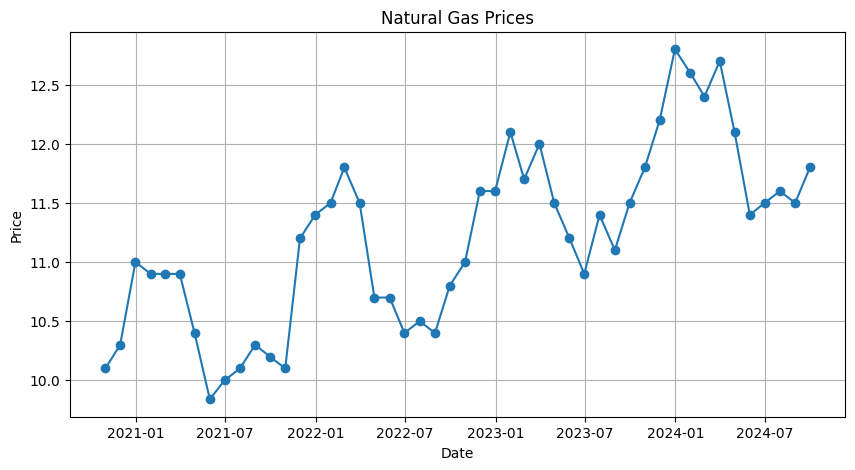

In [17]:
plt.figure(figsize=(10,5))
plt.plot(df["Dates"], df["Prices"], marker="o")
plt.title("Natural Gas Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [18]:
x = df["Dates"].map(pd.Timestamp.toordinal)
y = df["Prices"]

price_model = interp1d(
    x,
    y,
    kind="linear",
    fill_value="extrapolate"
)

In [19]:
def estimate_price(date):
    date = pd.to_datetime(date)
    return float(price_model(date.toordinal()))

In [20]:
print("Historical Estimate:")
print(estimate_price("2023-06-15"))

print("\nFuture Estimate:")
print(estimate_price("2025-06-30"))

Historical Estimate:
11.05

Future Estimate:
14.530000000000008


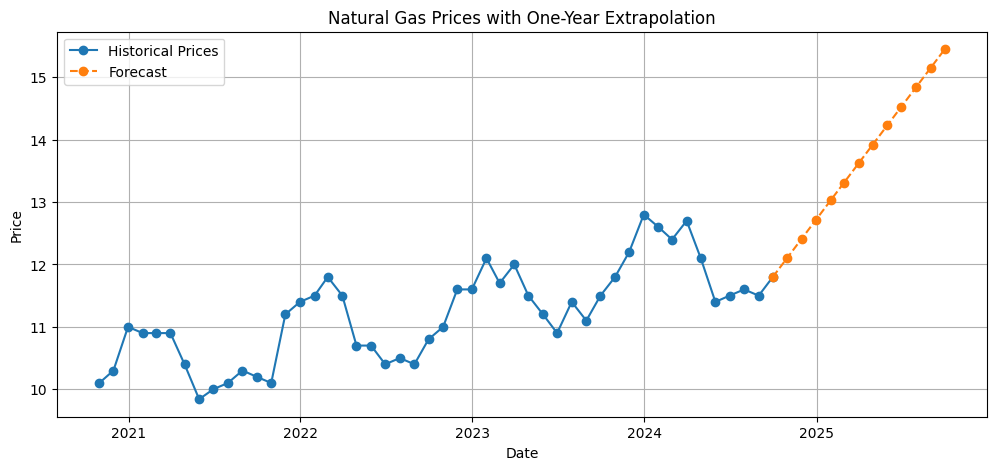

In [21]:
future_dates = pd.date_range(
    start=df["Dates"].max(),
    periods=13,
    freq="ME"
)

future_prices = [estimate_price(d) for d in future_dates]

plt.figure(figsize=(12,5))

plt.plot(
    df["Dates"],
    df["Prices"],
    marker="o",
    label="Historical Prices"
)

plt.plot(
    future_dates,
    future_prices,
    linestyle="--",
    marker="o",
    label="Forecast"
)

plt.title("Natural Gas Prices with One-Year Extrapolation")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
"""
Natural Gas Price Analysis

- Historical monthly natural gas prices are loaded from CSV.
- Linear interpolation is used to estimate prices between known dates.
- Linear extrapolation is used to estimate future prices.
- A function estimate_price(date) returns the estimated gas price
  for any input date.
"""

'\nNatural Gas Price Analysis\n\n- Historical monthly natural gas prices are loaded from CSV.\n- Linear interpolation is used to estimate prices between known dates.\n- Linear extrapolation is used to estimate future prices.\n- A function estimate_price(date) returns the estimated gas price\n  for any input date.\n'